In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

In [4]:
xs=np.arange(-5,5,0.25)

In [5]:
xs

array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
       -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
       -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
        1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
        4.  ,  4.25,  4.5 ,  4.75])

In [6]:
ys=f(xs)
ys

array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
        55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
        25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
         7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
         4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
        13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
        37.    ,  42.1875,  47.75  ,  53.6875])

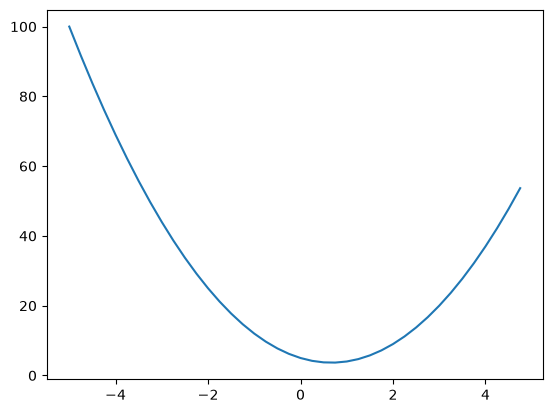

In [7]:
plt.plot(xs, ys)

In [8]:
h = 0.001
x = 3.0
f(x+h)-f(x)
(f(x+h)-f(x))/h

14.00300000000243

In [9]:
a=2.0
b=-3.0
c=10.0
d=a*b+c
print(d)

4.0


In [10]:
h=0.0001

#inputs
a=2.0
b=-3.0
c=10.0

d1 = a*b+c
a += h
d2 = a*b+c

print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [11]:
h=0.0001

#inputs
a=2.0
b=-3.0
c=10.0

d1 = a*b+c
b += h
d2 = a*b+c

print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)

d1 4.0
d2 4.0002
slope 2.0000000000042206


In [12]:
h=0.1

#inputs
a=2.0
b=-3.0
c=10.0

d1 = a*b+c
c += h
d2 = a*b+c

print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)

d1 4.0
d2 4.1
slope 0.9999999999999964


In [13]:
class Value:

  def __init__(self, data, children = (), _op='', label = ''):
    self.data = data
    self.grad = 0
    self._prev = set(children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value({self.data})"

  def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out
    
  def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

  def tanh(self):
      n = self.data
      t = (math.exp(2*n)-1)/(math.exp(2*n)+1)
      out = Value(t, (self, ), 'tanh')
      return out

a=Value(2.0, label = 'a')
b=Value(-3.0, label = 'b')
c=Value(10.0, label = 'c')
e = a*b; e.label = 'e'
d=e+c; d.label = 'd'
f = Value(-2.0, label = 'f')
L = d * f; L.label = 'L'
print(d._prev)
print(d._op)

{Value(10.0), Value(-6.0)}
+


In [14]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):

    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) #LR = left to right

    nodes, edges = trace(root)
    for n in  nodes:
        uid = str(id(n))
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape = 'record')
        if n._op:
            dot.node(name=uid + n._op, label = n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op) 

    return dot

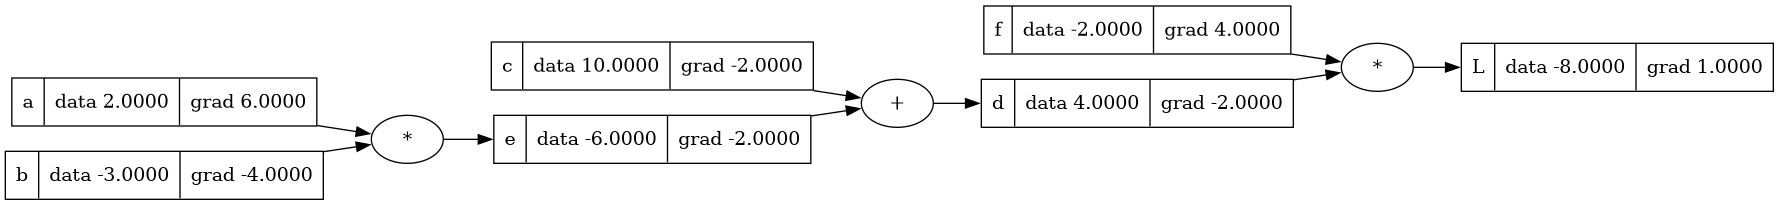

'micrograd_graph.png'

In [15]:
from IPython.display import Image, display
L.grad=1
d.grad=-2
f.grad=4
c.grad=-2
e.grad=-2
a.grad=6
b.grad=-4
dot = draw_dot(L)
display(Image(data=dot.pipe(format="png")))
dot.render("micrograd_graph", format="png", cleanup=True)

In [16]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f
print(L.data)

-7.286496


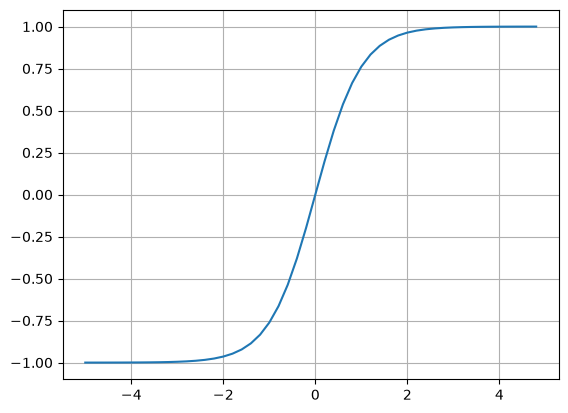

In [17]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();

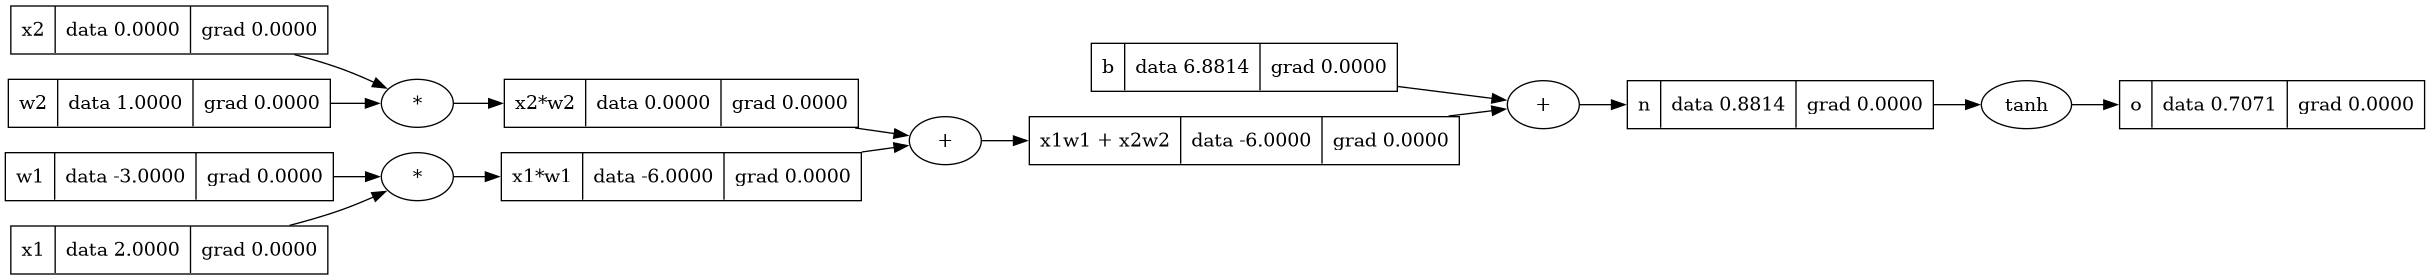

'neuron_graph.png'

In [35]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.8813735870195432, label = 'b')
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'

o=n.tanh()
o.label = 'o'

dot=draw_dot(o)
display(Image(data=dot.pipe(format="png")))
dot.render("neuron_graph", format="png", cleanup=True)


In [31]:
o.grad = 1

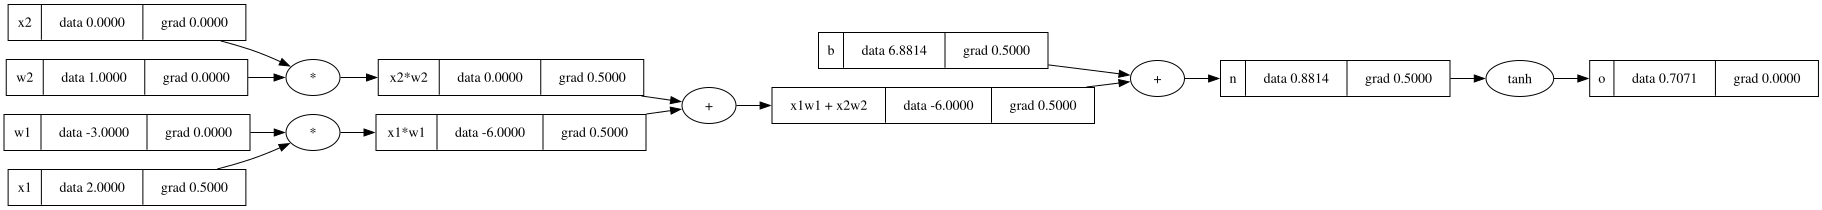

In [38]:
# o = tanh(n)
# do/dn = 1 - tanh(n) ** 2 = 1 - o**2
n.grad = 1 - o.data ** 2
b.grad = 0.5
x1w1x2w2.grad = 0.5
x1w1.grad = 0.5
x2w2.grad = 0.5

In [41]:
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

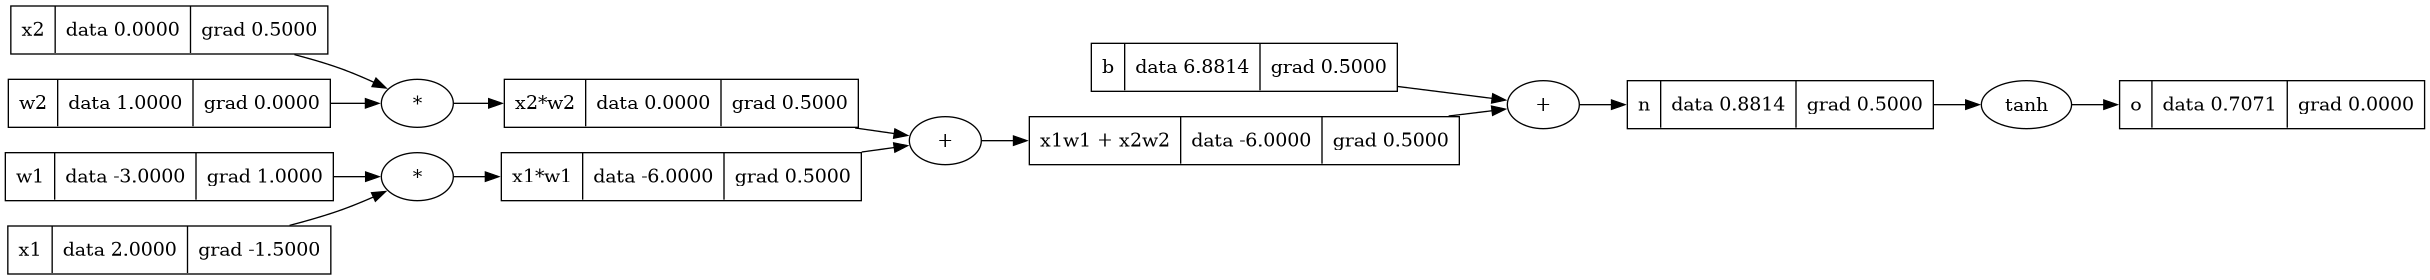

'neuron_graph_with_backpropagation.png'

In [42]:
dot=draw_dot(o)
display(Image(data=dot.pipe(format="png")))
dot.render("neuron_graph_with_backpropagation", format="png", cleanup=True)